# 05 · Forecast Models — LCL

**Purpose:** Train per-unit and pooled forecasting models for residential (LCL) electricity demand and produce predictions used by downstream reconciliation notebooks.

**Inputs**  
- `df_features_lcl.parquet` — feature-engineered hourly panel (from notebook 04)  
- `feature_list_lcl.json` — feature names produced by notebook 04

**Outputs (written to `data/output_lcl/`)**  
- `forecasts_individual_lcl.parquet` — per-unit **test-period** predictions, all models × approaches  
- `forecasts_individual_val_lcl.parquet` — per-unit **validation-period** predictions, used by nb07 to estimate Wb without test leakage  
- `forecasts_aggregate_lcl.parquet` — top-level direct **test-period** forecasts (and naive baselines) at the aggregate  
- `metrics_lcl.parquet` — RMSE / MAE / sMAPE per (draw × approach × model × unit) on test  
- `cv_params_lcl.csv` — best hyperparameters found by CV per draw

---

## Pipeline structure

1. Load nb04 features and add **cyclical** time encodings  
2. Define naive baselines: lag-168 (same hour last week, primary for residential), lag-24, lag-1  
3. Tune ElasticNet and LightGBM by time-series CV on a pooled training set  
4. Forecast in three modes: **local** (per-unit refits), **global** (one pooled model applied to all units), **aggregate** (top-level direct model)  
5. Predict on **both validation and test** windows. Test predictions are evaluated; val predictions are persisted separately for nb07 to estimate the MinT-WLS variance matrix `Wb` without leaking test data.  
6. Evaluate vs naive lag-168 baseline at unit and aggregate level

## Key design decisions

### Naive baseline
Uses **same-hour-last-week** (lag-168) as primary naive — more appropriate for residential demand with strong weekly patterns than first-difference persistence. Skill score = `1 − model_RMSE / naive_RMSE` (positive = beats naive).

### CV tuning
- **ElasticNetCV**: jointly searches `alpha` and `l1_ratio` (Ridge=0 ↔ Lasso=1)
- **LGBM RandomizedSearch**: `N_ITER_LGBM` iterations, `TimeSeriesSplit`
- Shallower trees / stronger regularisation than CHP — residential data is noisier
- Tuned once per draw on pooled training data

### Validation predictions
The val window is the `VAL_MONTHS` chunk between training and test (chronological per-unit split). The same trained models that produce test predictions also predict on the val window; those predictions are saved to a separate parquet so nb07 can estimate residual variance for `Wb` from genuinely held-out data.

### Prediction clipping
Residential demand cannot be negative — predictions are clipped to `[0, ∞)`.

## 1. Setup

Resolve the project root, load configuration, and import everything we need.

In [1]:
import os, sys, json, warnings, time
warnings.filterwarnings('ignore')

# Walk up to find the project root (folder containing config/)
_root = os.path.abspath('')
for _ in range(6):
    if os.path.isdir(os.path.join(_root, 'config')):
        break
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
os.chdir(_root)

import config.settings as _settings
cfg     = _settings.LCL
DATASET = 'lcl'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.linear_model    import ElasticNetCV
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics         import mean_squared_error, mean_absolute_error
from scipy.stats             import loguniform, randint
from lightgbm                import LGBMRegressor

print(f'Root   : {_root}')
print(f'Dataset: {DATASET}')

Root   : /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast
Dataset: lcl


## 2. Configuration

`SAMPLE_SIZE` and `N_DRAWS` come from `config/settings.py`. With multiple draws of households we get a stable estimate of mean RMSE without paying full sampling cost.

`TRAIN_MONTHS` / `VAL_MONTHS` define the train/val/test split chronologically per unit.

In [2]:
# ── Pipeline constants ────────────────────────────────────────────────────────
ID_COL       = cfg['ID_COL']                         # 'LCLid'
DEMAND_COL   = cfg['DEMAND_COL']                     # 'kWh'
OUTPUT_DIR   = os.path.join(_root, cfg['OUTPUT_DIR'])  # 'data/output_lcl/'
SAMPLE_SIZE  = cfg['SAMPLE_SIZE']
N_DRAWS      = cfg['N_DRAWS']
TRAIN_MONTHS = cfg['TRAIN_MONTHS']
VAL_MONTHS   = cfg['VAL_MONTHS']
RANDOM_SEED  = 42
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── CV budget ─────────────────────────────────────────────────────────────────
CV_FOLDS    = 3
N_ITER_LGBM = 5

print(f'ID_COL={ID_COL}  DEMAND_COL={DEMAND_COL}')
print(f'SAMPLE_SIZE={SAMPLE_SIZE}  N_DRAWS={N_DRAWS}  TRAIN_MONTHS={TRAIN_MONTHS}')
print(f'OUTPUT_DIR={OUTPUT_DIR}')

ID_COL=LCLid  DEMAND_COL=kWh
SAMPLE_SIZE=50  N_DRAWS=10  TRAIN_MONTHS=12
OUTPUT_DIR=/Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output_lcl/


## 3. Load engineered features from notebook 04

Notebook 04 produced the hourly panel with lag, rolling, calendar, weather, and tsfeatures. Temperature is included only if it has decent coverage (>50% non-null) — the LCL panel may not have a co-located weather station for every household.

In [3]:
# ── Load nb04 outputs ─────────────────────────────────────────────────────────
feat_path = os.path.join(OUTPUT_DIR, f'df_features_{DATASET}.parquet')
json_path = os.path.join(OUTPUT_DIR, f'feature_list_{DATASET}.json')
assert os.path.exists(feat_path), f'Missing: {feat_path}  →  run nb04 first.'

df_all = pd.read_parquet(feat_path)
df_all['timestamp'] = pd.to_datetime(df_all['timestamp'])
df_all = df_all.sort_values([ID_COL, 'timestamp']).reset_index(drop=True)

if os.path.exists(json_path):
    with open(json_path) as f:
        nb04_features = json.load(f)
    print(f'Loaded {len(nb04_features)} features from feature_list JSON')
else:
    nb04_features = [f for f in cfg.get('FEATURES_MANUAL', []) if f in df_all.columns]
    print(f'JSON not found — using {len(nb04_features)} manual features from config')

# Keep only features present in the dataframe
nb04_features = [f for f in nb04_features if f in df_all.columns]

# Drop temperature if too sparse
has_temp = ('temperature' in df_all.columns
            and df_all['temperature'].notna().mean() > 0.5)
if not has_temp and 'temperature' in nb04_features:
    nb04_features.remove('temperature')
    print('⚠️  Temperature sparse — excluded from feature list')

print(f'Shape : {df_all.shape}  |  Units: {df_all[ID_COL].nunique()}')
print(f'Time  : {df_all["timestamp"].min()}  →  {df_all["timestamp"].max()}')
print(f'Temperature usable: {has_temp}')

Loaded 34 features from feature_list JSON
Shape : (28477568, 50)  |  Units: 2072
Time  : 2012-07-26 09:00:00  →  2014-02-19 00:00:00
Temperature usable: True


## 4. Cyclical encodings + final feature list

Hour, weekday, and month are cyclic — hour 23 and hour 0 are adjacent, but a tree-based model fed the raw integers cannot see that. Sine/cosine encodings on the natural period give the model a continuous representation of the wrap-around. We drop the raw integer versions to avoid duplication.

In [4]:
# ── Cyclical encodings ────────────────────────────────────────────────────────
for col, period in [('hour', 24), ('weekday', 7), ('month', 12)]:
    df_all[f'{col}_sin'] = np.sin(2 * np.pi * df_all[col] / period)
    df_all[f'{col}_cos'] = np.cos(2 * np.pi * df_all[col] / period)

CYCLIC   = ['hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos']
DROP_RAW = {'hour', 'weekday', 'month'}

base = [f for f in nb04_features if f not in DROP_RAW]
seen = set()
FEATURE_COLS = [f for f in base + CYCLIC
                if f in df_all.columns and not (f in seen or seen.add(f))]

missing = [f for f in FEATURE_COLS if f not in df_all.columns]
assert not missing, f'Missing columns: {missing}'

print(f'Final feature set: {len(FEATURE_COLS)} columns')
print(f'  nb04 base (lags, calendar, tsfeatures): {len(base)}')
print(f'  cyclical                              : {len(CYCLIC)}')

Final feature set: 39 columns
  nb04 base (lags, calendar, tsfeatures): 33
  cyclical                              : 6


## 5. Naive baselines

Three persistence baselines, all in one place so the choice is explicit:

- **Lag-168 (weekly seasonal)** — `y_hat[t] = y[t-168]` — the **primary** baseline for LCL because residential load is strongly periodic by day-of-week.
- **Lag-24 (daily seasonal)** — `y_hat[t] = y[t-24]` — secondary, useful for diagnostics.
- **Lag-1 (first-difference persistence)** — included for completeness; a weak baseline for hourly residential data.

Skill score = `1 − model_RMSE / naive_RMSE` (positive = model beats the naive).

In [5]:
# ── Naive baselines: lag-168 (primary), lag-24, lag-1 ─────────────────────────
def naive_lag(y, lag):
    y    = np.asarray(y, float)
    yhat = np.full_like(y, np.nan)
    if len(y) > lag:
        yhat[lag:] = y[:-lag]
    return yhat

def rmse(y, yhat, mask=None):
    y    = np.asarray(y, float)
    yhat = np.asarray(yhat, float)
    fin  = np.isfinite(y) & np.isfinite(yhat)
    if mask is not None:
        fin = fin & np.asarray(mask, bool)[:len(fin)]
    if fin.sum() == 0:
        return np.nan
    return np.sqrt(np.mean((y[fin] - yhat[fin]) ** 2))

def naive_lag_rmse(y_true, lag):
    return rmse(y_true, naive_lag(y_true, lag))

print('Naive baselines defined: lag-168 (primary), lag-24, lag-1')

Naive baselines defined: lag-168 (primary), lag-24, lag-1


## 6. Train / val / test split and metrics

Chronological split per unit: first `TRAIN_MONTHS` for training, next `VAL_MONTHS` for validation (used only by CV folds inside tuning), the rest for test.

`compute_metrics` returns RMSE, MAE, and sMAPE on the finite intersection of true and predicted values.

In [6]:
# ── Train / val / test split + metrics ────────────────────────────────────────
def split_data(df):
    t0    = df['timestamp'].min()
    t_val = t0 + pd.DateOffset(months=TRAIN_MONTHS)
    t_tst = t_val + pd.DateOffset(months=VAL_MONTHS)
    return (
        df[df['timestamp'] <  t_val],
        df[(df['timestamp'] >= t_val) & (df['timestamp'] < t_tst)],
        df[df['timestamp'] >= t_tst],
    )

def get_xy(df, feat_cols=None):
    cols  = [c for c in (feat_cols or FEATURE_COLS) if c in df.columns]
    clean = df.dropna(subset=cols + [DEMAND_COL])
    return clean[cols].values, clean[DEMAND_COL].values, clean['timestamp'].values

def compute_metrics(yt, yp):
    yt = np.asarray(yt, float)
    yp = np.asarray(yp, float)
    fin = np.isfinite(yt) & np.isfinite(yp)
    yt, yp = yt[fin], yp[fin]
    if len(yt) == 0:
        return dict(rmse=np.nan, mae=np.nan, smape=np.nan)
    rmse_ = np.sqrt(mean_squared_error(yt, yp))
    mae_  = mean_absolute_error(yt, yp)
    denom = (np.abs(yt) + np.abs(yp)) / 2
    smape = np.mean(np.where(denom > 0, np.abs(yt - yp) / denom, 0)) * 100
    return dict(rmse=rmse_, mae=mae_, smape=smape)

## 7. CV-tuned model factories

**`tune_elasticnet`** — `ElasticNetCV` searches `alpha` (regularisation strength) and `l1_ratio` (Ridge ↔ Lasso) jointly with `TimeSeriesSplit`.

**`tune_lgbm`** — `RandomizedSearchCV` over LightGBM hyperparameters. Compared to CHP, the LCL search uses **shallower trees** (`num_leaves` 8–64 vs 15–128), **larger minimum leaf size** (`min_child_samples` 15–80 vs 10–60), and **stronger L2** (`reg_lambda` 0.1–20 vs 0.01–10) — residential households produce noisier signals than industrial CHPs so we regularise harder.

In [7]:
def tune_elasticnet(X_train, y_train):
    tscv = TimeSeriesSplit(n_splits=CV_FOLDS)
    en   = ElasticNetCV(
        l1_ratio     = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
        alphas       = np.logspace(-4, 2, 30),
        cv           = tscv,
        max_iter     = 5000,
        random_state = RANDOM_SEED,
    )
    pipe = Pipeline([('sc', StandardScaler()), ('m', en)])
    pipe.fit(X_train, y_train)
    return pipe

def tune_lgbm(X_train, y_train, n_iter=N_ITER_LGBM):
    tscv = TimeSeriesSplit(n_splits=CV_FOLDS)
    param_dist = {
        'num_leaves'       : randint(8, 64),       # shallower for noisy residential
        'learning_rate'    : loguniform(0.01, 0.2),
        'min_child_samples': randint(15, 80),      # larger minimum for small households
        'reg_lambda'       : loguniform(0.1, 20.0),
        'subsample'        : [0.6, 0.7, 0.8, 0.9],
        'colsample_bytree' : [0.6, 0.7, 0.8, 0.9, 1.0],
    }
    base = LGBMRegressor(
        n_estimators=100, max_depth=5, reg_alpha=0.1,
        random_state=RANDOM_SEED, verbosity=-1,
        n_jobs=1, deterministic=True, force_row_wise=True,
    )
    search = RandomizedSearchCV(
        estimator           = base,
        param_distributions = param_dist,
        n_iter              = n_iter,
        cv                  = tscv,
        scoring             = 'neg_root_mean_squared_error',
        refit               = True,
        random_state        = RANDOM_SEED,
        n_jobs              = 1,
    )
    search.fit(X_train, y_train)
    return search.best_estimator_, search.best_params_

## 8. Forecasting functions

Three modes:

- **Local** — refit per unit using the globally-tuned hyperparameters as starting points.  
- **Global** — apply the pooled, globally-tuned model directly to each unit's test rows.  
- **Aggregate** — sum unit demand, build aggregate-level features (lag-24/48/168, rolling mean, calendar/cyclic, optional temperature), tune a fresh ElasticNet and LightGBM directly on the aggregate. **Naive lag-24 and lag-168** baselines are recorded as dedicated 'models' for clean downstream comparison — same convention as the CHP notebook.

Each unit-level forecast function now returns predictions for **both the val window and the test window** in a `{'val': {...}, 'test': {...}}` dict. Val predictions come from the same trained models and are persisted separately so nb07 can estimate the MinT-WLS variance matrix `Wb` without leaking test data.

All model predictions are **clipped to `[0, ∞)`** because residential demand cannot be negative.


In [8]:
# ── Forecasting functions ─────────────────────────────────────────────────────
# Each function returns a {'val': {...}, 'test': {...}} dict so the same trained
# model produces predictions for both windows. Val predictions are persisted to
# forecasts_individual_val_{ds}.parquet for nb07's Wb estimation.

def forecast_local(uid, df_unit, en_pipe, lgbm_model):
    train, val, test = split_data(df_unit)
    Xtr, ytr, _      = get_xy(train)
    Xva, yva, ts_va  = get_xy(val)
    Xte, yte, ts_te  = get_xy(test)
    if len(Xtr) < 50 or len(Xte) < 24:
        return {'val': {}, 'test': {}}

    en_u = Pipeline([
        ('sc', StandardScaler()),
        ('m',  ElasticNetCV(
            l1_ratio = [en_pipe.named_steps['m'].l1_ratio_],
            alphas   = [en_pipe.named_steps['m'].alpha_],
            cv       = min(3, max(2, len(Xtr) // 200)),
            max_iter = 5000,
        )),
    ])
    en_u.fit(Xtr, ytr)

    lgbm_u = LGBMRegressor(**lgbm_model.get_params())
    lgbm_u.fit(Xtr, ytr)

    test_out = {
        'LR'  : (ts_te, yte, np.clip(en_u.predict(Xte),   0, None)),
        'LGBM': (ts_te, yte, np.clip(lgbm_u.predict(Xte), 0, None)),
    }
    val_out = {}
    if len(Xva) > 0:
        val_out = {
            'LR'  : (ts_va, yva, np.clip(en_u.predict(Xva),   0, None)),
            'LGBM': (ts_va, yva, np.clip(lgbm_u.predict(Xva), 0, None)),
        }
    return {'val': val_out, 'test': test_out}


def forecast_global(sample_units, df_sample, en_pipe, lgbm_model):
    out = {'val': {'LR': {}, 'LGBM': {}}, 'test': {'LR': {}, 'LGBM': {}}}
    for uid in sample_units:
        d = df_sample[df_sample[ID_COL] == uid]
        _, va, te = split_data(d)
        Xva, yva, ts_va = get_xy(va)
        Xte, yte, ts_te = get_xy(te)
        if len(Xte) < 24:
            continue
        out['test']['LR'][uid]   = (ts_te, yte, np.clip(en_pipe.predict(Xte),    0, None))
        out['test']['LGBM'][uid] = (ts_te, yte, np.clip(lgbm_model.predict(Xte), 0, None))
        if len(Xva) > 0:
            out['val']['LR'][uid]   = (ts_va, yva, np.clip(en_pipe.predict(Xva),    0, None))
            out['val']['LGBM'][uid] = (ts_va, yva, np.clip(lgbm_model.predict(Xva), 0, None))
    return out


def forecast_aggregate(sample_units, df_sample):
    """Train a top-level direct model on the summed demand of `sample_units`.

    Aggregate-level features:
      - kWh_lag24 / 48 / 168 + rollmean24      (recomputed on the summed series)
      - calendar + cyclical                    (invariant across units)
      - temperature                            (if available — invariant across units)

    Naive lag-24 and lag-168 are returned alongside LR/LGBM so downstream
    notebooks can compare against them with no extra computation.

    Returns ({test predictions dict}, lgbm_params) — aggregate val predictions
    are not currently saved (Wb is estimated only at the unit level).
    """
    agg = (
        df_sample[df_sample[ID_COL].isin(sample_units)]
        .groupby('timestamp')[DEMAND_COL].sum()
        .reset_index().sort_values('timestamp')
    )

    agg['kWh_lag24']      = agg[DEMAND_COL].shift(24)
    agg['kWh_lag48']      = agg[DEMAND_COL].shift(48)
    agg['kWh_lag168']     = agg[DEMAND_COL].shift(168)
    agg['kWh_rollmean24'] = agg[DEMAND_COL].shift(1).rolling(24, min_periods=12).mean()

    if has_temp:
        temp = (
            df_sample[df_sample[ID_COL].isin(sample_units)]
            .groupby('timestamp')['temperature'].mean().reset_index()
        )
        agg = agg.merge(temp, on='timestamp', how='left')

    invariant = ['timestamp', 'year', 'is_weekend', 'is_holiday',
                 'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos',
                 'month_sin', 'month_cos']
    invariant = [c for c in invariant if c in df_sample.columns]
    ref = (
        df_sample[df_sample[ID_COL] == sample_units[0]][invariant]
        .drop_duplicates('timestamp')
    )
    agg = agg.merge(ref, on='timestamp', how='left')

    agg_feat_cols = [c for c in FEATURE_COLS if c in agg.columns]

    train, _, test = split_data(agg)
    Xtr, ytr, _    = get_xy(train, agg_feat_cols)

    clean_test = test.dropna(subset=agg_feat_cols + [DEMAND_COL])
    Xte      = clean_test[agg_feat_cols].values
    yte      = clean_test[DEMAND_COL].values
    ts       = clean_test['timestamp'].values
    naive24  = clean_test['kWh_lag24'].values
    naive168 = clean_test['kWh_lag168'].values

    if len(Xtr) < 100 or len(Xte) < 24:
        return None

    en_agg           = tune_elasticnet(Xtr, ytr)
    lgbm_agg, params = tune_lgbm(Xtr, ytr)

    return {
        'LR'      : (ts, yte, np.clip(en_agg.predict(Xte),   0, None)),
        'LGBM'    : (ts, yte, np.clip(lgbm_agg.predict(Xte), 0, None)),
        'Naive24' : (ts, yte, naive24),
        'Naive168': (ts, yte, naive168),
    }, params

## 9. Validate the unit pool

Drop units with too few rows to support a `TRAIN_MONTHS + VAL_MONTHS + 1` test split.

In [9]:
# ── Validate unit pool ────────────────────────────────────────────────────────
all_units   = sorted(df_all[ID_COL].unique().tolist())
min_rows    = (TRAIN_MONTHS + VAL_MONTHS + 1) * 30 * 24
valid_units = [u for u in all_units if len(df_all[df_all[ID_COL] == u]) >= min_rows]

print(f'Total : {len(all_units)}')
print(f'Valid : {len(valid_units)} (≥ {min_rows:,} rows)')
print(f'Sample: {SAMPLE_SIZE}')
if len(valid_units) < SAMPLE_SIZE:
    print(f'⚠️  Adjusting SAMPLE_SIZE  →  {len(valid_units)}')
    SAMPLE_SIZE = len(valid_units)

Total : 2072
Valid : 2072 (≥ 10,080 rows)
Sample: 50


## 10. Main forecasting loop

For each draw:
1. Sample `SAMPLE_SIZE` valid units without replacement.
2. Build a pooled training set (all units' training rows stacked) and CV-tune one ElasticNet and one LightGBM.
3. Run **local**, **global**, and **aggregate** forecasts.
4. Record per-row predictions and per-(approach, model, unit) metrics.

A small `_record` helper avoids repeating the per-row append loop three times.

In [10]:
# ── Main forecasting loop ─────────────────────────────────────────────────────
rng              = np.random.default_rng(RANDOM_SEED)
ind_recs         = []   # test predictions  → forecasts_individual_lcl.parquet
val_recs         = []   # val  predictions  → forecasts_individual_val_lcl.parquet
agg_recs         = []   # test aggregate    → forecasts_aggregate_lcl.parquet
met_recs         = []   # test metrics      → metrics_lcl.parquet
best_params_log  = []
t0               = time.time()

def _record_test(draw, approach, model, uid, ts, yt, yp):
    """Append per-row test predictions and a metrics row."""
    for t, a, b in zip(ts, yt, yp):
        ind_recs.append(dict(draw=draw, approach=approach, model=model,
                             **{ID_COL: uid}, timestamp=t,
                             y_true=float(a), y_pred=float(b)))
    met_recs.append(dict(draw=draw, approach=approach, model=model,
                         **{ID_COL: uid}, **compute_metrics(yt, yp)))

def _record_val(draw, approach, model, uid, ts, yt, yp):
    """Append per-row val predictions (no metrics — used only by nb07 for Wb)."""
    for t, a, b in zip(ts, yt, yp):
        val_recs.append(dict(draw=draw, approach=approach, model=model,
                             **{ID_COL: uid}, timestamp=t,
                             y_true=float(a), y_pred=float(b)))

for draw in range(N_DRAWS):
    sample = sorted(rng.choice(valid_units, size=SAMPLE_SIZE, replace=False).tolist())
    df_s   = df_all[df_all[ID_COL].isin(sample)].copy()

    # Pooled training set
    pool_train = []
    for uid in sample:
        tr, _, _    = split_data(df_s[df_s[ID_COL] == uid])
        Xtr, ytr, _ = get_xy(tr)
        if len(Xtr) >= 50:
            pool_train.append((Xtr, ytr))
    if not pool_train:
        print(f'Draw {draw+1:02d}/{N_DRAWS} — no usable pool, skipping')
        continue
    Xpool = np.vstack([x for x, _ in pool_train])
    ypool = np.concatenate([y for _, y in pool_train])

    print(f'Draw {draw+1:02d}/{N_DRAWS} — ElasticNet...', end=' ', flush=True)
    en_global = tune_elasticnet(Xpool, ypool)
    en_params = {'alpha'   : en_global.named_steps['m'].alpha_,
                 'l1_ratio': en_global.named_steps['m'].l1_ratio_}

    print('LGBM...', end=' ', flush=True)
    lgbm_global, lgbm_params = tune_lgbm(Xpool, ypool)
    best_params_log.append({'draw': draw, **en_params, **lgbm_params})
    print(f'α={en_params["alpha"]:.4f}  l1={en_params["l1_ratio"]:.1f}  '
          f'leaves={lgbm_params["num_leaves"]}')

    # Local — both val and test
    for uid in sample:
        result = forecast_local(uid, df_s[df_s[ID_COL] == uid], en_global, lgbm_global)
        for mn, (ts, yt, yp) in result['test'].items():
            _record_test(draw, 'local', mn, uid, ts, yt, yp)
        for mn, (ts, yt, yp) in result['val'].items():
            _record_val(draw, 'local', mn, uid, ts, yt, yp)

    # Global — both val and test
    g_result = forecast_global(sample, df_s, en_global, lgbm_global)
    for mn, uid_dict in g_result['test'].items():
        for uid, (ts, yt, yp) in uid_dict.items():
            _record_test(draw, 'global', mn, uid, ts, yt, yp)
    for mn, uid_dict in g_result['val'].items():
        for uid, (ts, yt, yp) in uid_dict.items():
            _record_val(draw, 'global', mn, uid, ts, yt, yp)

    # Aggregate (test only — Wb is estimated at unit level, not aggregate level)
    res = forecast_aggregate(sample, df_s)
    if res:
        agg_preds, _ = res
        for mn, (ts, yt, yp) in agg_preds.items():
            for t, a, b in zip(ts, yt, yp):
                agg_recs.append(dict(draw=draw, approach='aggregate', model=mn,
                                     timestamp=t, y_true=float(a), y_pred=float(b)))
            met_recs.append(dict(draw=draw, approach='aggregate', model=mn,
                                 **{ID_COL: 'aggregate'},
                                 **compute_metrics(yt, yp)))

    print(f'   [{(time.time() - t0) / 60:.1f} min elapsed]')

print(f'\nDone.  Test rows: {len(ind_recs):,}  |  Val rows: {len(val_recs):,}  '
      f'|  Aggregate rows: {len(agg_recs):,}')

Draw 01/10 — ElasticNet... LGBM... α=0.0117  l1=0.9  leaves=10
   [0.4 min elapsed]
Draw 02/10 — ElasticNet... LGBM... α=0.0117  l1=1.0  leaves=10
   [0.8 min elapsed]
Draw 03/10 — ElasticNet... LGBM... α=0.0011  l1=1.0  leaves=10
   [1.3 min elapsed]
Draw 04/10 — ElasticNet... LGBM... α=0.0189  l1=1.0  leaves=10
   [1.7 min elapsed]
Draw 05/10 — ElasticNet... LGBM... α=0.0073  l1=0.9  leaves=10
   [2.1 min elapsed]
Draw 06/10 — ElasticNet... LGBM... α=0.0073  l1=1.0  leaves=10
   [2.5 min elapsed]
Draw 07/10 — ElasticNet... LGBM... α=0.0073  l1=1.0  leaves=10
   [2.9 min elapsed]
Draw 08/10 — ElasticNet... LGBM... α=0.0073  l1=0.9  leaves=10
   [3.3 min elapsed]
Draw 09/10 — ElasticNet... LGBM... α=0.0117  l1=0.9  leaves=10
   [3.7 min elapsed]
Draw 10/10 — ElasticNet... LGBM... α=0.0788  l1=0.1  leaves=10
   [4.2 min elapsed]

Done.  Test rows: 8,480,000  |  Val rows: 1,488,000  |  Aggregate rows: 169,600


## 11. Save outputs

Write four parquet files and the CV-params CSV to `OUTPUT_DIR`:

- `forecasts_individual_{ds}.parquet` — test-period unit predictions (consumed by nb06, nb07, nb08)
- `forecasts_individual_val_{ds}.parquet` — val-period unit predictions (consumed by nb07 for Wb estimation, no test leakage)
- `forecasts_aggregate_{ds}.parquet` — test-period aggregate predictions including naive baselines
- `metrics_{ds}.parquet` — test-period metrics per (draw × approach × model × unit)


In [11]:
# ── Build dataframes and persist ──────────────────────────────────────────────
forecasts_individual = pd.DataFrame(ind_recs)
forecasts_individual['timestamp'] = pd.to_datetime(forecasts_individual['timestamp'])

forecasts_individual_val = pd.DataFrame(val_recs)
if len(forecasts_individual_val) > 0:
    forecasts_individual_val['timestamp'] = pd.to_datetime(forecasts_individual_val['timestamp'])

forecasts_aggregate = pd.DataFrame(agg_recs)
forecasts_aggregate['timestamp'] = pd.to_datetime(forecasts_aggregate['timestamp'])

metrics_df = pd.DataFrame(met_recs)

for name, df_ in [
    ('forecasts_individual',     forecasts_individual),
    ('forecasts_individual_val', forecasts_individual_val),
    ('forecasts_aggregate',      forecasts_aggregate),
    ('metrics',                  metrics_df),
]:
    path = os.path.join(OUTPUT_DIR, f'{name}_{DATASET}.{SAMPLE_SIZE}.{N_DRAWS}.parquet')
    df_.to_parquet(path, index=False)
    print(f'Saved {path}  shape={df_.shape}')

pd.DataFrame(best_params_log).to_csv(
    os.path.join(OUTPUT_DIR, f'cv_params_{DATASET}.{SAMPLE_SIZE}.{N_DRAWS}.csv'), index=False
)
print(f'Saved cv_params_{DATASET}.{SAMPLE_SIZE}.{N_DRAWS}.csv')

Saved /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output_lcl/forecasts_individual_lcl.50.10.parquet  shape=(8480000, 7)
Saved /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output_lcl/forecasts_individual_val_lcl.50.10.parquet  shape=(1488000, 7)
Saved /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output_lcl/forecasts_aggregate_lcl.50.10.parquet  shape=(169600, 6)
Saved /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output_lcl/metrics_lcl.50.10.parquet  shape=(2040, 7)
Saved cv_params_lcl.50.10.csv


## 12. Quality report — unit-level naive baselines + skill scores

Skill score is reported vs **lag-168 naive** (the LCL-appropriate primary), with **lag-24** shown alongside for context. Computed on draw 0 to avoid duplicating identical `y_true` series across approaches.

In [12]:
# ── Quality report: unit-level naive baseline + skill scores ─────────────────
unit_naive_24, unit_naive_168 = [], []

# Filter to one (approach, model, draw) combo to get one y_true series per unit
ref_view = forecasts_individual[
    (forecasts_individual['approach'] == 'global') &
    (forecasts_individual['model']    == 'LGBM') &
    (forecasts_individual['draw']     == 0)
]

for uid in ref_view[ID_COL].unique():
    yt = ref_view[ref_view[ID_COL] == uid].sort_values('timestamp')['y_true'].values
    if len(yt) <= 168:
        continue
    unit_naive_24 .append(naive_lag_rmse(yt, 24))
    unit_naive_168.append(naive_lag_rmse(yt, 168))

naive_24  = np.nanmean(unit_naive_24)
naive_168 = np.nanmean(unit_naive_168)

print('=' * 70)
print('QUALITY REPORT — LCL  (unit level)')
print('=' * 70)
print(f'{"Naive RMSE (mean across units)":<40}  {"value":>10}')
print('-' * 56)
print(f'{"Lag-168 (same hour last week, primary)":<40}  {naive_168:>10.4f}')
print(f'{"Lag-24  (same hour yesterday)":<40}  {naive_24:>10.4f}')

avg = (
    metrics_df[metrics_df['approach'].isin(['local', 'global'])]
    .groupby(['approach', 'model'])[['rmse', 'mae', 'smape']]
    .mean().round(4)
)

print()
print('--- Mean metrics per approach × model ---')
print(avg.to_string())

print(f'\nSkill scores  (positive = beats naive)')
print(f'{"":20s}  {"vs lag-168":>10}  {"vs lag-24":>10}')
print('-' * 44)
for (ap, mn), row in avg.iterrows():
    s168 = 1 - row['rmse'] / naive_168
    s24  = 1 - row['rmse'] / naive_24
    flag168 = '✅' if s168 > 0 else '⚠️'
    flag24  = '✅' if s24  > 0 else '⚠️'
    print(f'  {ap:8s} {mn:6s}:  {s168:+.3f} {flag168}   {s24:+.3f} {flag24}')

QUALITY REPORT — LCL  (unit level)
Naive RMSE (mean across units)                 value
--------------------------------------------------------
Lag-168 (same hour last week, primary)        0.4026
Lag-24  (same hour yesterday)                 0.3827

--- Mean metrics per approach × model ---
                  rmse     mae    smape
approach model                         
global   LGBM   0.3214  0.1988  47.8693
         LR     0.3335  0.2088  50.0360
local    LGBM   0.3098  0.1934  44.7626
         LR     0.3183  0.2052  49.2558

Skill scores  (positive = beats naive)
                      vs lag-168   vs lag-24
--------------------------------------------
  global   LGBM  :  +0.202 ✅   +0.160 ✅
  global   LR    :  +0.172 ✅   +0.129 ✅
  local    LGBM  :  +0.231 ✅   +0.191 ✅
  local    LR    :  +0.209 ✅   +0.168 ✅


In [13]:
naive_unit = (
    metrics_df[
        (metrics_df['model'] == 'Naive24') &
        (metrics_df['approach'].isin(['local', 'global']))  # unit-level rows only
    ][['rmse', 'mae', 'smape']]
    .mean()
    .round(4)
)
print(naive_unit)

rmse    NaN
mae     NaN
smape   NaN
dtype: float64


In [14]:
# 1. What approach values actually exist for Naive24 rows?
print(metrics_df[metrics_df['model'] == 'Naive24']['approach'].value_counts())

# 2. What columns does metrics_df actually have?
print(metrics_df.columns.tolist())

# 3. Look at raw Naive24 rows directly, no aggregation
print(metrics_df[metrics_df['model'] == 'Naive24'].head(10))

approach
aggregate    10
Name: count, dtype: int64
['draw', 'approach', 'model', 'LCLid', 'rmse', 'mae', 'smape']
      draw   approach    model      LCLid      rmse       mae      smape
202      0  aggregate  Naive24  aggregate  3.897415  2.830042  13.482319
406      1  aggregate  Naive24  aggregate  3.497772  2.658916  12.254772
610      2  aggregate  Naive24  aggregate  4.818012  3.452456  15.377846
814      3  aggregate  Naive24  aggregate  3.494396  2.633948  12.008504
1018     4  aggregate  Naive24  aggregate  4.071707  2.978603  13.654968
1222     5  aggregate  Naive24  aggregate  3.206369  2.332405  12.079601
1426     6  aggregate  Naive24  aggregate  3.065063  2.284927  11.996425
1630     7  aggregate  Naive24  aggregate  4.765709  3.431312  13.881234
1834     8  aggregate  Naive24  aggregate  3.774543  2.884984  11.346841
2038     9  aggregate  Naive24  aggregate  4.245693  3.088416  12.983292


In [15]:
# ── Quality report: unit-level naive baseline + skill scores (all 10 draws) ───
draw_naive_24_rmse,  draw_naive_168_rmse  = [], []
draw_naive_24_mae,   draw_naive_168_mae   = [], []
draw_naive_24_smape, draw_naive_168_smape = [], []

for draw in sorted(forecasts_individual['draw'].unique()):
    ref_view = forecasts_individual[
        (forecasts_individual['approach'] == 'global') &
        (forecasts_individual['model']    == 'LGBM') &
        (forecasts_individual['draw']     == draw)
    ]

    unit_rmse_24, unit_rmse_168 = [], []
    unit_mae_24,  unit_mae_168  = [], []
    unit_smape_24, unit_smape_168 = [], []

    for uid in ref_view[ID_COL].unique():
        yt = ref_view[ref_view[ID_COL] == uid].sort_values('timestamp')['y_true'].values
        if len(yt) <= 168:
            continue
        pred_24  = naive_lag(yt, 24)
        pred_168 = naive_lag(yt, 168)

        unit_rmse_24.append(naive_lag_rmse(yt, 24))
        unit_rmse_168.append(naive_lag_rmse(yt, 168))
        unit_mae_24.append(mae(yt, pred_24))
        unit_mae_168.append(mae(yt, pred_168))
        unit_smape_24.append(smape(yt, pred_24))
        unit_smape_168.append(smape(yt, pred_168))

    if not unit_rmse_24:
        continue

    # per-draw mean across units
    draw_naive_24_rmse.append(np.nanmean(unit_rmse_24))
    draw_naive_168_rmse.append(np.nanmean(unit_rmse_168))
    draw_naive_24_mae.append(np.nanmean(unit_mae_24))
    draw_naive_168_mae.append(np.nanmean(unit_mae_168))
    draw_naive_24_smape.append(np.nanmean(unit_smape_24))
    draw_naive_168_smape.append(np.nanmean(unit_smape_168))

def _mean_std(vals):
    return np.mean(vals), np.std(vals)

naive_24_rmse,   naive_24_rmse_std   = _mean_std(draw_naive_24_rmse)
naive_168_rmse,  naive_168_rmse_std  = _mean_std(draw_naive_168_rmse)
naive_24_mae,    naive_24_mae_std    = _mean_std(draw_naive_24_mae)
naive_168_mae,   naive_168_mae_std   = _mean_std(draw_naive_168_mae)
naive_24_smape,  naive_24_smape_std  = _mean_std(draw_naive_24_smape)
naive_168_smape, naive_168_smape_std = _mean_std(draw_naive_168_smape)

print('=' * 70)
print('QUALITY REPORT — LCL  (unit level, mean ± std across 10 draws)')
print('=' * 70)
print(f'{"":45}  {"RMSE":>14}  {"MAE":>14}  {"sMAPE":>14}')
print('-' * 95)
print(f'{"Lag-168 (same hour last week, primary)":<45}  '
      f'{naive_168_rmse:>6.4f}±{naive_168_rmse_std:<6.4f}  '
      f'{naive_168_mae:>6.4f}±{naive_168_mae_std:<6.4f}  '
      f'{naive_168_smape:>6.2f}±{naive_168_smape_std:<5.2f}%')
print(f'{"Lag-24  (same hour yesterday)":<45}  '
      f'{naive_24_rmse:>6.4f}±{naive_24_rmse_std:<6.4f}  '
      f'{naive_24_mae:>6.4f}±{naive_24_mae_std:<6.4f}  '
      f'{naive_24_smape:>6.2f}±{naive_24_smape_std:<5.2f}%')

avg = (
    metrics_df[metrics_df['approach'].isin(['local', 'global'])]
    .groupby(['approach', 'model'])[['rmse', 'mae', 'smape']]
    .mean().round(4)
)

print()
print('--- Mean metrics per approach × model (trained models) ---')
print(avg.to_string())

print(f'\nSkill scores  (positive = beats naive, using Lag-24 as primary per Section 4)')
print(f'{"":20s}  {"vs lag-168":>10}  {"vs lag-24":>10}')
print('-' * 44)
for (ap, mn), row in avg.iterrows():
    s168 = 1 - row['rmse'] / naive_168_rmse
    s24  = 1 - row['rmse'] / naive_24_rmse
    flag168 = '✅' if s168 > 0 else '⚠️'
    flag24  = '✅' if s24  > 0 else '⚠️'
    print(f'  {ap:8s} {mn:6s}:  {s168:+.3f} {flag168}   {s24:+.3f} {flag24}')

NameError: name 'mae' is not defined

## 13. Aggregate-level naive baselines + skill scores

The aggregate sum behaves much better than individual households (noise averages out). Lag-24 and lag-168 are computed **per draw** then averaged — reporting `mean ± std` makes draw-to-draw stability visible.

In [16]:
# ── Aggregate-level naive RMSE: per draw, then mean ───────────────────────────
draw_naive_24  = []
draw_naive_168 = []

for draw in sorted(forecasts_individual['draw'].unique()):
    agg_true_d = (
        forecasts_individual[
            (forecasts_individual['model']    == 'LGBM') &
            (forecasts_individual['approach'] == 'global') &
            (forecasts_individual['draw']     == draw)
        ]
        .groupby('timestamp')['y_true']
        .sum()
        .sort_index()
        .values
    )
    if len(agg_true_d) <= 168:
        continue
    draw_naive_24 .append(rmse(agg_true_d, naive_lag(agg_true_d, 24)))
    draw_naive_168.append(rmse(agg_true_d, naive_lag(agg_true_d, 168)))

mean_naive_24  = np.mean(draw_naive_24)
mean_naive_168 = np.mean(draw_naive_168)
std_naive_24   = np.std(draw_naive_24)
std_naive_168  = np.std(draw_naive_168)

print('Aggregate naive RMSE (mean ± std across draws):')
print(f'  Lag-168 : {mean_naive_168:.3f} ± {std_naive_168:.3f}   (primary)')
print(f'  Lag-24  : {mean_naive_24:.3f} ± {std_naive_24:.3f}')
print(f'\nPer-draw lag-168: {[round(v, 2) for v in draw_naive_168]}')
print(f'Per-draw lag-24 : {[round(v, 2) for v in draw_naive_24]}')

# Trained aggregate models (and their built-in naive baselines)
agg_metrics = (
    metrics_df[metrics_df['approach'] == 'aggregate']
    .groupby('model')['rmse'].mean()
    .round(3)
)
print(f'\nTrained aggregate models (mean RMSE across draws):')
print(agg_metrics.to_string())

print(f'\nSkill scores vs lag-168 naive (mean across draws):')
for model, m_rmse in agg_metrics.items():
    if model not in ('Naive24', 'Naive168'):
        skill = 1 - m_rmse / mean_naive_168
        flag  = '✅' if skill > 0 else '⚠️'
        print(f'  {model:8s}: {skill:+.3f}  {flag}')

Aggregate naive RMSE (mean ± std across draws):
  Lag-168 : 3.840 ± 0.398   (primary)
  Lag-24  : 3.890 ± 0.572

Per-draw lag-168: [np.float64(3.93), np.float64(3.55), np.float64(4.25), np.float64(3.9), np.float64(3.74), np.float64(3.23), np.float64(3.18), np.float64(4.37), np.float64(3.95), np.float64(4.3)]
Per-draw lag-24 : [np.float64(3.9), np.float64(3.5), np.float64(4.82), np.float64(3.5), np.float64(4.08), np.float64(3.21), np.float64(3.07), np.float64(4.77), np.float64(3.78), np.float64(4.25)]

Trained aggregate models (mean RMSE across draws):
model
LGBM        2.945
LR          3.137
Naive168    3.803
Naive24     3.884

Skill scores vs lag-168 naive (mean across draws):
  LGBM    : +0.233  ✅
  LR      : +0.183  ✅


In [17]:
# ── Trained aggregate models + naive baselines: RMSE, MAE, sMAPE ──────────────
agg_metrics = (
    metrics_df[metrics_df['approach'] == 'aggregate']
    .groupby('model')[['rmse', 'mae', 'smape']].mean()
    .round(3)
)
print('Aggregate models (mean RMSE / MAE / sMAPE % across draws):')
print(agg_metrics.to_string())

print(f'\nSkill scores vs lag-168 naive (mean across draws):')
naive_168_row = agg_metrics.loc['Naive168']
for model, row in agg_metrics.iterrows():
    if model not in ('Naive24', 'Naive168'):
        skill_rmse = 1 - row['rmse'] / naive_168_row['rmse']
        skill_mae  = 1 - row['mae']  / naive_168_row['mae']
        flag = '✅' if skill_rmse > 0 else '⚠️'
        print(f'  {model:8s}: RMSE skill {skill_rmse:+.3f}  MAE skill {skill_mae:+.3f}  {flag}')

Aggregate models (mean RMSE / MAE / sMAPE % across draws):
           rmse    mae   smape
model                         
LGBM      2.945  2.216  10.154
LR        3.137  2.380  10.996
Naive168  3.803  2.846  13.073
Naive24   3.884  2.858  12.907

Skill scores vs lag-168 naive (mean across draws):
  LGBM    : RMSE skill +0.226  MAE skill +0.221  ✅
  LR      : RMSE skill +0.175  MAE skill +0.164  ✅


## 14. CV-tuned hyperparameter summary

Quick look at what the random search and ElasticNetCV converged on across draws — useful for spotting whether the search ranges are well-calibrated.

In [18]:
# ── Hyperparameter summary across draws ───────────────────────────────────────
params_df = pd.DataFrame(best_params_log)
print('Tuned hyperparameters (across draws):')
print(params_df.describe().round(4).to_string())
print('\nl1_ratio distribution (0=Ridge, 1=Lasso):')
print(params_df['l1_ratio'].value_counts().sort_index().to_string())

Tuned hyperparameters (across draws):
          draw    alpha  l1_ratio  colsample_bytree  learning_rate  min_child_samples  num_leaves  reg_lambda  subsample
count  10.0000  10.0000   10.0000              10.0        10.0000               10.0        10.0     10.0000       10.0
mean    4.5000   0.0163    0.8700               0.8         0.0396               38.0        10.0      0.1115        0.7
std     3.0277   0.0224    0.2751               0.0         0.0000                0.0         0.0      0.0000        0.0
min     0.0000   0.0011    0.1000               0.8         0.0396               38.0        10.0      0.1115        0.7
25%     2.2500   0.0073    0.9000               0.8         0.0396               38.0        10.0      0.1115        0.7
50%     4.5000   0.0095    0.9500               0.8         0.0396               38.0        10.0      0.1115        0.7
75%     6.7500   0.0117    1.0000               0.8         0.0396               38.0        10.0      0.1115      

## 15. Spot check — actual vs predicted

Two-panel diagnostic for one draw:

- **Top:** aggregate-level — actual, direct aggregate forecast, and bottom-up sums (global + local).
- **Bottom:** unit-level — the median-MAE household, with both global and local LGBM predictions.

The model often misses sharp peaks at the unit level — this is the headline reason hierarchical reconciliation matters: the aggregate signal is much smoother and more predictable, and reconciliation lets the bottom forecasts borrow strength from it.

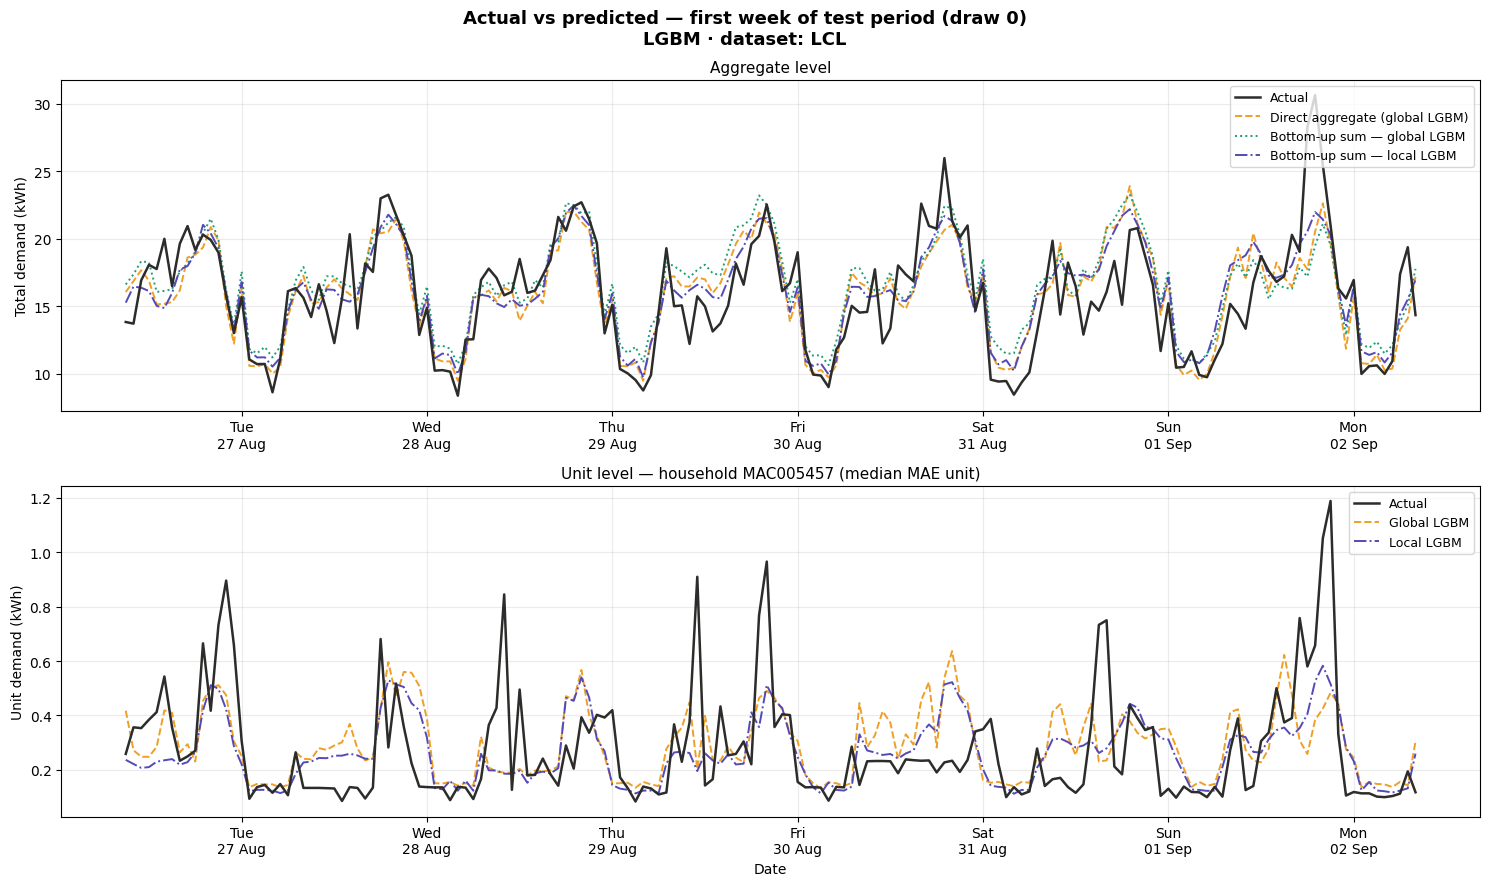

Saved -> fig_actual_vs_predicted_lcl.png

✅ Notebook 05 (LCL) complete — proceed to 06_coherency.ipynb


In [19]:
# ── Spot check: one draw, aggregate + median-MAE unit ────────────────────────
PLOT_DRAW = 0   # change to 1, 2, 3 ... up to N_DRAWS-1
WINDOW_H  = 24 * 7

def first_week(df):
    df = df.sort_values('timestamp')
    if len(df) == 0:
        return df
    t_start = df['timestamp'].iloc[0]
    return df[df['timestamp'] < t_start + pd.Timedelta(hours=WINDOW_H)]

# Median-MAE unit for this draw
unit_mae = (
    metrics_df[
        (metrics_df['approach'] == 'global') &
        (metrics_df['draw']     == PLOT_DRAW)
    ]
    .groupby(ID_COL)['mae'].mean().sort_values()
)
med_unit = unit_mae.index[len(unit_mae) // 2]

# Aggregate panel data
agg_week = first_week(
    forecasts_aggregate[
        (forecasts_aggregate['model'] == 'LGBM') &
        (forecasts_aggregate['draw']  == PLOT_DRAW)
    ]
)
for ap in ['global', 'local']:
    bu = (
        forecasts_individual[
            (forecasts_individual['model']    == 'LGBM') &
            (forecasts_individual['approach'] == ap) &
            (forecasts_individual['draw']     == PLOT_DRAW)
        ]
        .groupby('timestamp')['y_pred'].sum()
        .reset_index().rename(columns={'y_pred': f'bu_{ap}'})
    )
    agg_week = agg_week.merge(bu, on='timestamp', how='left')

# Unit panel data
unit_global = first_week(
    forecasts_individual[
        (forecasts_individual[ID_COL]     == med_unit) &
        (forecasts_individual['approach'] == 'global') &
        (forecasts_individual['model']    == 'LGBM') &
        (forecasts_individual['draw']     == PLOT_DRAW)
    ]
).rename(columns={'y_pred': 'pred_global'})

unit_local = first_week(
    forecasts_individual[
        (forecasts_individual[ID_COL]     == med_unit) &
        (forecasts_individual['approach'] == 'local') &
        (forecasts_individual['model']    == 'LGBM') &
        (forecasts_individual['draw']     == PLOT_DRAW)
    ]
)[['timestamp', 'y_pred']].rename(columns={'y_pred': 'pred_local'})

unit_week = unit_global.merge(unit_local, on='timestamp', how='left')

# Plot
COLORS = {
    'actual'        : '#2C2C2A',
    'global_direct' : '#EF9F27',
    'global_bu'     : '#1D9E75',
    'local_bu'      : '#534AB7',
    'pred_global'   : '#EF9F27',
    'pred_local'    : '#534AB7',
}

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=False)
fig.suptitle(
    f'Actual vs predicted — first week of test period (draw {PLOT_DRAW})\n'
    f'LGBM · dataset: {DATASET.upper()}',
    fontsize=13, fontweight='bold', y=0.98
)

# Aggregate panel
ax = axes[0]
ax.plot(agg_week['timestamp'], agg_week['y_true'],
        color=COLORS['actual'], linewidth=1.8, label='Actual', zorder=3)
ax.plot(agg_week['timestamp'], agg_week['y_pred'],
        color=COLORS['global_direct'], linewidth=1.4, linestyle='--',
        label='Direct aggregate (global LGBM)', zorder=2)
if 'bu_global' in agg_week.columns:
    ax.plot(agg_week['timestamp'], agg_week['bu_global'],
            color=COLORS['global_bu'], linewidth=1.4, linestyle=':',
            label='Bottom-up sum — global LGBM', zorder=2)
if 'bu_local' in agg_week.columns:
    ax.plot(agg_week['timestamp'], agg_week['bu_local'],
            color=COLORS['local_bu'], linewidth=1.4, linestyle='-.',
            label='Bottom-up sum — local LGBM', zorder=2)
ax.set_title('Aggregate level', fontsize=11)
ax.set_ylabel(f'Total demand ({DEMAND_COL})')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%a\n%d %b'))
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.25)

# Unit panel
ax2 = axes[1]
ax2.plot(unit_week['timestamp'], unit_week['y_true'],
         color=COLORS['actual'], linewidth=1.8, label='Actual', zorder=3)
ax2.plot(unit_week['timestamp'], unit_week['pred_global'],
         color=COLORS['pred_global'], linewidth=1.4, linestyle='--',
         label='Global LGBM', zorder=2)
ax2.plot(unit_week['timestamp'], unit_week['pred_local'],
         color=COLORS['pred_local'], linewidth=1.4, linestyle='-.',
         label='Local LGBM', zorder=2)
ax2.set_title(f'Unit level — household {med_unit} (median MAE unit)', fontsize=11)
ax2.set_ylabel(f'Unit demand ({DEMAND_COL})')
ax2.set_xlabel('Date')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%a\n%d %b'))
ax2.xaxis.set_major_locator(mdates.DayLocator())
ax2.legend(fontsize=9, loc='upper right')
ax2.grid(True, alpha=0.25)

fig_dir = os.path.join(_root, 'results', 'figures')
os.makedirs(fig_dir, exist_ok=True)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, f'fig_actual_vs_predicted_{DATASET}.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> fig_actual_vs_predicted_{DATASET}.png')
print('\n✅ Notebook 05 (LCL) complete — proceed to 06_coherency.ipynb')

In [20]:
print(f"Current config: SAMPLE_SIZE={SAMPLE_SIZE}  N_DRAWS={N_DRAWS}")
import glob, os, time
expected = os.path.join(OUTPUT_DIR, f'forecasts_aggregate_lcl.{SAMPLE_SIZE}.{N_DRAWS}.parquet')
print(f"Expected path from today's run: {expected}")
print(f"Exists: {os.path.exists(expected)}")
if os.path.exists(expected):
    print(f"Modified: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(os.path.getmtime(expected)))}")

print()
print("All forecasts_aggregate_lcl* files:")
for f in sorted(glob.glob(os.path.join(OUTPUT_DIR, 'forecasts_aggregate_lcl*'))):
    print(f"  {f}  (modified {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(os.path.getmtime(f)))})")

Current config: SAMPLE_SIZE=50  N_DRAWS=10
Expected path from today's run: /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output_lcl/forecasts_aggregate_lcl.50.10.parquet
Exists: True
Modified: 2026-07-29 13:06:01

All forecasts_aggregate_lcl* files:
  /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output_lcl/forecasts_aggregate_lcl.20.1.10.parquet  (modified 2026-06-20 01:02:35)
  /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output_lcl/forecasts_aggregate_lcl.20.10.parquet  (modified 2026-07-28 13:54:00)
  /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output_lcl/forecasts_aggregate_lcl.20.30.parquet  (modified 2026-05-14 14:54:58)
  /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output_lcl/forecasts_aggregate_lcl.20.parquet  (modified 2026-05-14 14:52:23)
  /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output_lcl/forecast